# Harmonic loss

https://arxiv.org/abs/2502.01628

In the last layer of a neural network, instead of computing the logit $z_i$ as
$$
    z_i = \mathbf{w}_i^T \mathbf{x}
$$
and then applying the softmax function 
$$
    y_i = \dfrac{e^{z_i}}{\sum_{j=1}^D e^{z_j}}
$$
the **Harmonic loss** is applied by computing the $i$-th logit as the $L_2$ distance from $\mathbf{x}$ to $\mathbf{w}_i$, i.e., 
$$
    d_i = ||\mathbf{x} - \mathbf{w}_i||_2
$$
and instead of the softmax, the harmonic max (HarMax) is applied
$$
    y_i = \dfrac{\dfrac{1}{d_i^n}}{\sum_{j=1}^D \dfrac{1}{d_i^n}}
$$
where $n$ is the temperature parameter controlling the heavy-tailedness of the probability distribution. $n$ is chosen to be $n \sim \sqrt{D}$ with the motivation that an embedding is initialized from a $D$-dimensional Gaussian distribution, and thus to control the variance of distances as we scale $D$, the square root of $D$ is chosen. 

In [1]:
import torch
from torch import nn
from torch.nn import functional as F

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Simple classification dataset

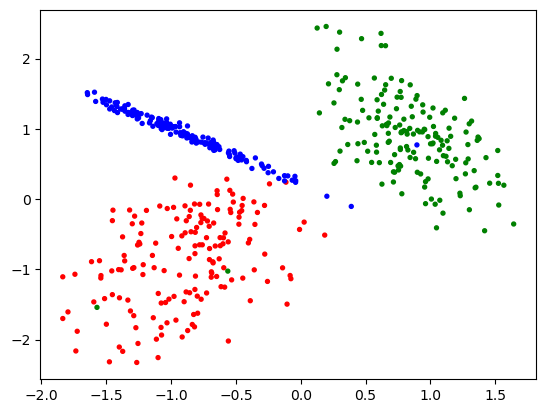

In [82]:
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap
cmap1 = ListedColormap(['red', 'blue', 'green'])
cmap2 = ListedColormap(['orange', 'cyan', 'lime'])

# maak classificatie dataset 
X, y = make_classification(
    n_samples=500, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_repeated=0, 
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.8
)
X = (X - X.mean())/X.std() # standaardiseer dataset (mean 0, variance 1)

# maak meshgrid om beslisgrenzen te laten zien
xmin = X[:, 0].min(); xmax = X[:, 0].max()
ymin = X[:, 1].min(); ymax = X[:, 1].max()
xx, yy = np.meshgrid(
    np.linspace(xmin-.5, xmax+.5, 100),
    np.linspace(ymin-.5, ymax+.5, 100)
)
D = np.vstack((xx.flatten(), yy.flatten())).T

plt.scatter(X[:, 0], X[:, 1], s=8, c=y, cmap=cmap1)
plt.show()

In [83]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(
        self, 
        X: np.ndarray,
        y: np.ndarray,
    ):
        # convert data into torch tensors
        self.X = torch.tensor(X).to(torch.float32)
        self.y = torch.tensor(y).to(torch.long)
        
    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return len(self.X)

In [84]:
from torch.utils.data import DataLoader, random_split

batch_size = 16

# create dataset
dataset = CustomDataset(X, y)
# randomly split the dataset into train, validation, test sets
train_set, val_set, test_set = random_split(dataset, [0.8, 0.1, 0.1])

# create dataloaders from train, val, test sets
train_dataloader = DataLoader(train_set, batch_size, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size, shuffle=False)

# loss function (cross-entropy because we are dealing with a classification problem)
# criterion = # nn.CrossEntropyLoss()

## Simple Harmonic MLP Model 

In [100]:
class StandardMLP(nn.Module):
    
    def __init__(self, d: int, harmonic: bool):
        super().__init__()
        self.fc1 = nn.Linear(2, d)
        self.w = nn.Parameter(torch.empty((d, 3)))
        nn.init.xavier_normal_(self.w)
        self.harmonic = harmonic
        self.logits = torch.tensor(0)
        self.z = torch.tensor(0)

    def forward(self, x):
        # input x must have shape: (batch_size, 2)

        # z shape: (batch_size, d) 
        self.z = F.relu(self.fc1(x))

        # y shape: (batch_size, 3)
        if self.harmonic:
            self.logits = torch.norm(self.z[..., None, :] - self.w.T, dim=-1, p=2)
            n = self.z.shape[-1]**.5
            y = 1/(self.logits**n)
            y = y/y.sum(dim=-1, keepdims=True)
        else:
            self.logits = self.z @ self.w
            y = F.softmax(self.logits, dim=-1)

        return y
    
mlp = StandardMLP(d=5, harmonic=True)

x = torch.randn(32, 2)
mlp(x).shape, mlp.logits.shape, mlp.z.shape

(torch.Size([32, 3]), torch.Size([32, 3]), torch.Size([32, 5]))

### Train model

In [101]:
def train_model(model, max_epochs, train_dataloader, val_dataloader, optimizer, device, verbose=False):
    # maintain history of train/val losses
    train_losses = []
    val_losses = []

    for epoch in range(max_epochs): 
        
        batch_loss = []
        for batch_X, batch_y in train_dataloader:
            
            y_pred = model(batch_X.to(device))
            loss = F.nll_loss(torch.log(y_pred), batch_y.to(device))

            batch_loss.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_losses.append(sum(batch_loss) / len(batch_loss))
        
        with torch.no_grad():

            batch_loss = []
            for batch_X, batch_y in val_dataloader:
                
                y_pred = model(batch_X.to(device))
                loss = F.nll_loss(torch.log(y_pred), batch_y.to(device)) #criterion(y_pred, batch_y.to(device))

                batch_loss.append(loss.item())

            val_losses.append(sum(batch_loss) / len(batch_loss))

        if verbose: print(f"{epoch=} \ttrain_loss = {train_losses[-1]:.4f}\tval_loss = {val_losses[-1]:.4f}")
    
    return train_losses, val_losses

In [124]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Training constants
learning_rate = 1e-4
max_epochs = 1000

# define model
model = StandardMLP(d=3, harmonic=True).to(device)

# define optimizer (Adam)
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

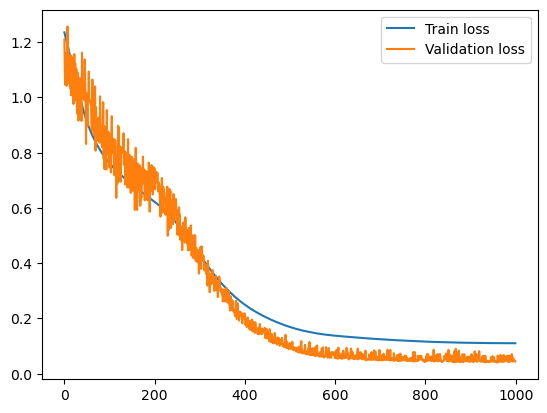

In [125]:
train_losses, val_losses = train_model(model, max_epochs, train_dataloader, val_dataloader, optimizer, device)

plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()

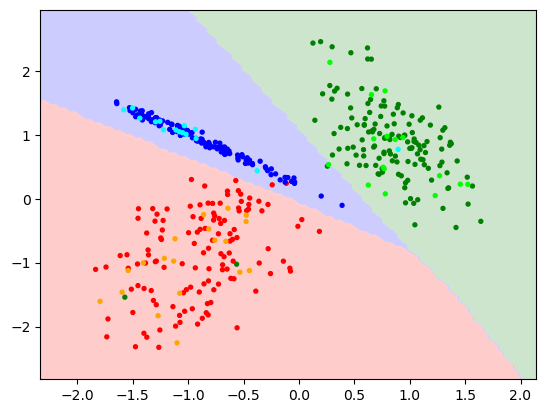

In [126]:
y_pred = model(torch.Tensor(D).to(device)).cpu()

decisions = y_pred.reshape(*xx.shape, 3).argmax(dim=-1)

plt.contourf(xx, yy, decisions, cmap=cmap1, alpha=0.2, antialiased=True)
plt.scatter(train_set[:][0][:, 0], train_set[:][0][:, 1], s=8, c=train_set[:][1], cmap=cmap1)
plt.scatter(test_set[:][0][:, 0], test_set[:][0][:, 1], s=8, c=test_set[:][1], cmap=cmap2)
plt.show()

In [127]:
test_loss = 0

with torch.no_grad():

    for batch_X, batch_y in test_dataloader:
        
        y_pred = model(batch_X.to(device))
        loss = F.nll_loss(torch.log(y_pred), batch_y.to(device))

        test_loss += loss.item()

test_loss / len(test_dataloader)

0.1464061364531517

### Analyze unembedding matrix

In [128]:
y_preds, y_true, z_vals, logits = [], [], [], []

with torch.no_grad():

    for batch_X, batch_y in train_dataloader:
        
        y_pred = model(batch_X.to(device))

        y_preds.append(y_pred.detach().cpu().numpy())
        y_true.append(batch_y.numpy())
        z_vals.append(model.z.detach().cpu().numpy())
        logits.append(model.logits.detach().cpu().numpy())
        
y_preds = np.concatenate(y_preds)
y_true = np.concatenate(y_true)
z_vals = np.concatenate(z_vals)
logits = np.concatenate(logits)

In [129]:
y_preds.shape, y_true.shape, z_vals.shape, logits.shape

((400, 3), (400,), (400, 3), (400, 3))

In [131]:
import numpy as np
import plotly.graph_objects as go

# Create the 3D plot using plotly
fig = go.Figure()

w_numpy = model.w.detach().cpu().numpy()

fig.add_trace(go.Scatter3d(
    x=w_numpy[:, 0], y=w_numpy[:, 1], z=w_numpy[:, 2],
    mode='markers', 
))

# fig.add_trace(go.Scatter3d(
#     x=logits[:, 0], y=logits[:, 1], z=logits[:, 2],
#     mode='markers',
#     marker=dict(
#         size=6,
#         color=y_true,
#         colorscale='thermal',
#         opacity=0.8
#     )
# ))

fig.add_trace(go.Scatter3d(
    x=z_vals[:, 0], y=z_vals[:, 1], z=z_vals[:, 2],
    mode='markers',
    marker=dict(
        size=6,
        color=y_true,
        colorscale='thermal',
        opacity=0.8
    )
))

# Update layout for better visualization
# Update layout to increase plot size
fig.update_layout(
    scene=dict(
        xaxis=dict(title='class 1'),
        yaxis=dict(title='class 1'),
        zaxis=dict(title='class 1'),
        aspectmode='cube'
    ),
    title='Unembedding matrix for 3 classes',
    margin=dict(l=0, r=0, b=0, t=40),
    width=1000,  # Set width of the plot
    height=800   # Set height of the plot
)

# Show the plot
fig.show()


## MNIST

In [138]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class HarmonicCNN(nn.Module):
    
    def __init__(self, d: int, harmonic: bool):
        super().__init__()
        self.lenet = nn.Sequential(
            # conv block 1: 28 -> 12
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0),   # 28 -> 24
            nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),                                          # 24 -> 12
            # conv block 2: 12 -> 4
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),  # 12 -> 8
            nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),                                          # 8 -> 4
            # dense MLP
            nn.Flatten(),                                                                   # 16*4*4 = 256 units
            nn.Linear(256, 120), nn.ReLU(),
            nn.Linear(120, d)
        )
        self.w = nn.Parameter(torch.empty((d, 10)))
        nn.init.xavier_normal_(self.w)
        self.harmonic = harmonic
        self.logits = torch.tensor(0)
        self.z = torch.tensor(0)

    def forward(self, x):
        # input x must have shape: (batch_size, 1, 28, 28)

        # z shape: (batch_size, d) 
        self.z = F.relu(self.lenet(x))

        # y shape: (batch_size, 10)
        if self.harmonic:
            self.logits = torch.norm(self.z[..., None, :] - self.w.T, dim=-1, p=2)
            n = self.z.shape[-1]**.5
            y = 1/(self.logits**n)
            y = y/y.sum(dim=-1, keepdims=True)
        else:
            self.logits = self.z @ self.w
            y = F.softmax(self.logits, dim=-1)

        return y


X = torch.randn(1, 1, 28, 28).to(device)
cnn = HarmonicCNN(d=32, harmonic=True).to(device)
cnn(X)

tensor([[0.1394, 0.1744, 0.1176, 0.0857, 0.0344, 0.0600, 0.0796, 0.0585, 0.0993,
         0.1510]], device='cuda:0', grad_fn=<DivBackward0>)

In [5]:
import torchvision
import torchvision.transforms as transforms

DOWNLOAD_PATH = '../datasets'

# normalize so that the mean of the data is zero and the variance is one
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=True, download=True, transform=transform)
test_val = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=False, download=True, transform=transform)
test, val = torch.utils.data.random_split(test_val, [0.5, 0.5])

epoch: 0	train loss: 1.7246	val loss: 0.3074
epoch: 1	train loss: 0.1995	val loss: 0.1247
epoch: 2	train loss: 0.1181	val loss: 0.0936
epoch: 3	train loss: 0.0913	val loss: 0.0811
epoch: 4	train loss: 0.0761	val loss: 0.0731


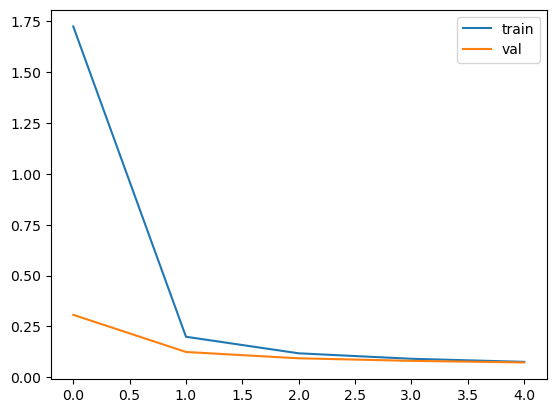

In [139]:
from torch.utils.data import DataLoader

EPOCHS = 5

cnn = HarmonicCNN(d=32, harmonic=True).to(device)

train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=True)
val_loader = DataLoader(val, batch_size=len(val), shuffle=True)

optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

train_history = []
val_history = []

for e in range(EPOCHS):
    batch_history = []
    # TRAIN STEP
    for images, labels in train_loader:
        # convert images to the correct device (GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        # predict and compute loss
        preds = cnn(images)
        loss = F.nll_loss(torch.log(preds), labels)
        batch_history.append(loss.item())
        # optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_history.append(np.mean(batch_history))

    batch_history = []
    # VALIDATION STEP
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = cnn(images)
            loss = F.nll_loss(torch.log(preds), labels)
            batch_history.append(loss.item())
        val_history.append(np.mean(batch_history))
    
    print(f"epoch: {e}\ttrain loss: {train_history[-1]:.4f}\tval loss: {val_history[-1]:.4f}")

plt.plot(train_history, label='train')
plt.plot(val_history, label='val')
plt.legend()

In [140]:
# TEST STEP
with torch.no_grad():
    test_loss = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = cnn(images)
        loss = F.nll_loss(torch.log(preds), labels)
        test_loss += loss.item()
    print(f"test loss: {test_loss / len(test_loader)}")

test loss: 0.07139363139867783


In [143]:
y_preds, y_true, z_vals, logits = [], [], [], []

with torch.no_grad():

    for batch_X, batch_y in test_loader:
        
        y_pred = cnn(batch_X.to(device))

        y_preds.append(y_pred.detach().cpu().numpy())
        y_true.append(batch_y.numpy())
        z_vals.append(cnn.z.detach().cpu().numpy())
        logits.append(cnn.logits.detach().cpu().numpy())
        
y_preds = np.concatenate(y_preds)
y_true = np.concatenate(y_true)
z_vals = np.concatenate(z_vals)
logits = np.concatenate(logits)

In [145]:
y_preds.shape, y_true.shape, z_vals.shape, logits.shape, cnn.w.shape

((5000, 10), (5000,), (5000, 32), (5000, 10), torch.Size([32, 10]))

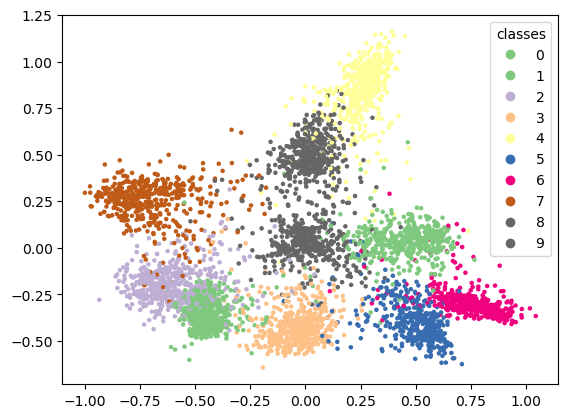

In [149]:
from sklearn.decomposition import PCA

z_pca = PCA(n_components=2).fit_transform(z_vals)

sc2 = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=y_true.tolist(), s=5, cmap='Accent')
plt.legend(*sc2.legend_elements(), title='classes')
# plt.title('Last hidden layer projected onto 2 PCs')

plt.show()

## Reproducing MNIST experiment

In [147]:
class MNISTMLP(nn.Module):
    
    def __init__(self, harmonic: bool, scale: float=10**.5, norm: float=None):
        super().__init__()
        # self.fc1 = nn.Linear(28*28, 10)
        self.w = nn.Parameter(torch.empty((28*28, 10)))
        nn.init.normal_(self.w, mean=0, std=1/28.)
        self.harmonic = harmonic
        self.logits = torch.tensor(0)
        self.norm = norm
        self.scale = scale

    def forward(self, x):
        # input x must have shape: (batch_size, 28*28)

        # y shape: (batch_size, 3)
        if self.harmonic:
            if self.norm == float('inf'):
                self.logits, _ = torch.max(torch.abs(x[..., None, :] - self.w.T), dim=-1)
            else:
                self.logits = torch.norm(x[..., None, :] - self.w.T, dim=-1, p=self.norm)
            y = 1/(self.logits**self.scale)
            y = y/y.sum(dim=-1, keepdims=True)
        else:
            self.logits = x @ self.w
            y = F.softmax(self.logits, dim=-1)

        return y
    
x = torch.randn(1, 28*28)
mnist_mlp = MNISTMLP(harmonic=True, norm=float('inf'))
mnist_mlp(x)

tensor([[0.0999, 0.0979, 0.0990, 0.0966, 0.0962, 0.1036, 0.0990, 0.1034, 0.1006,
         0.1038]], grad_fn=<DivBackward0>)

In [148]:
import torchvision
import torchvision.transforms as transforms

DOWNLOAD_PATH = '../datasets'

# normalize so that the mean of the data is zero and the variance is one
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_val = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=True, download=True, transform=transform)
test = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=False, download=True, transform=transform)
train, val = torch.utils.data.random_split(train_val, [55000, 5000])

len(train), len(val), len(test)

(55000, 5000, 10000)

In [149]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=True)
val_loader = DataLoader(val, batch_size=len(val), shuffle=True)

In [150]:
def train_MNIST(model, lr, epochs, verbose=False):
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_history = []
    val_history = []

    for e in range(epochs):
        batch_history = []
        # TRAIN STEP
        for images, labels in train_loader:
            # convert images to the correct device (GPU or CPU)
            images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
            # predict and compute loss
            preds = model(images)
            loss = F.nll_loss(torch.log(preds), labels)
            batch_history.append(loss.item())
            # optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_history.append(np.mean(batch_history))

        batch_history = []
        # VALIDATION STEP
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
                preds = model(images)
                loss = F.nll_loss(torch.log(preds), labels)
                batch_history.append(loss.item())
            val_history.append(np.mean(batch_history))
        
        if verbose: print(f"epoch: {e}\ttrain loss: {train_history[-1]:.4f}\tval loss: {val_history[-1]:.4f}")
    
    return train_history, val_history

In [182]:
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10
learning_rate = 0.001

models = {
    "standard MLP": MNISTMLP(harmonic=False).to(device),
    r"harmonic $L_2$ MLP with $n \sim \sqrt{D}$": MNISTMLP(harmonic=True, norm=2.0, scale=4.5 * 10**.5).to(device),
    r"harmonic $L_1$ MLP with $n \sim D$": MNISTMLP(harmonic=True, norm=1.0, scale=0.7*10).to(device),
    r"harmonic $L_{\infty}$ MLP with $n \sim \sqrt{\log D}$": MNISTMLP(harmonic=True, norm=float('inf'), scale=2.2*(2*math.log(10))**.5).to(device),
}

In [183]:
train_histories, val_histories = [], []

for name, model in list(models.items()):
    
    print(f"training {name} ...")
    train_history, val_history = train_MNIST(model, learning_rate, EPOCHS, verbose=True)

    train_histories.append(train_history)
    val_histories.append(val_history)

training standard MLP ...
epoch: 0	train loss: 0.4863	val loss: 0.3538
epoch: 1	train loss: 0.3310	val loss: 0.3357
epoch: 2	train loss: 0.3106	val loss: 0.3310
epoch: 3	train loss: 0.3033	val loss: 0.3292
epoch: 4	train loss: 0.2968	val loss: 0.3161
epoch: 5	train loss: 0.2908	val loss: 0.3109
epoch: 6	train loss: 0.2892	val loss: 0.3093
epoch: 7	train loss: 0.2860	val loss: 0.3071
epoch: 8	train loss: 0.2834	val loss: 0.3052
epoch: 9	train loss: 0.2795	val loss: 0.3183
training harmonic $L_2$ MLP with $n \sim \sqrt{D}$ ...
epoch: 0	train loss: 1.7558	val loss: 1.2833
epoch: 1	train loss: 1.0032	val loss: 0.7943
epoch: 2	train loss: 0.6916	val loss: 0.6100
epoch: 3	train loss: 0.5700	val loss: 0.5345
epoch: 4	train loss: 0.5182	val loss: 0.5025
epoch: 5	train loss: 0.4965	val loss: 0.4896
epoch: 6	train loss: 0.4880	val loss: 0.4848
epoch: 7	train loss: 0.4847	val loss: 0.4838
epoch: 8	train loss: 0.4832	val loss: 0.4822
epoch: 9	train loss: 0.4826	val loss: 0.4818
training harmonic $

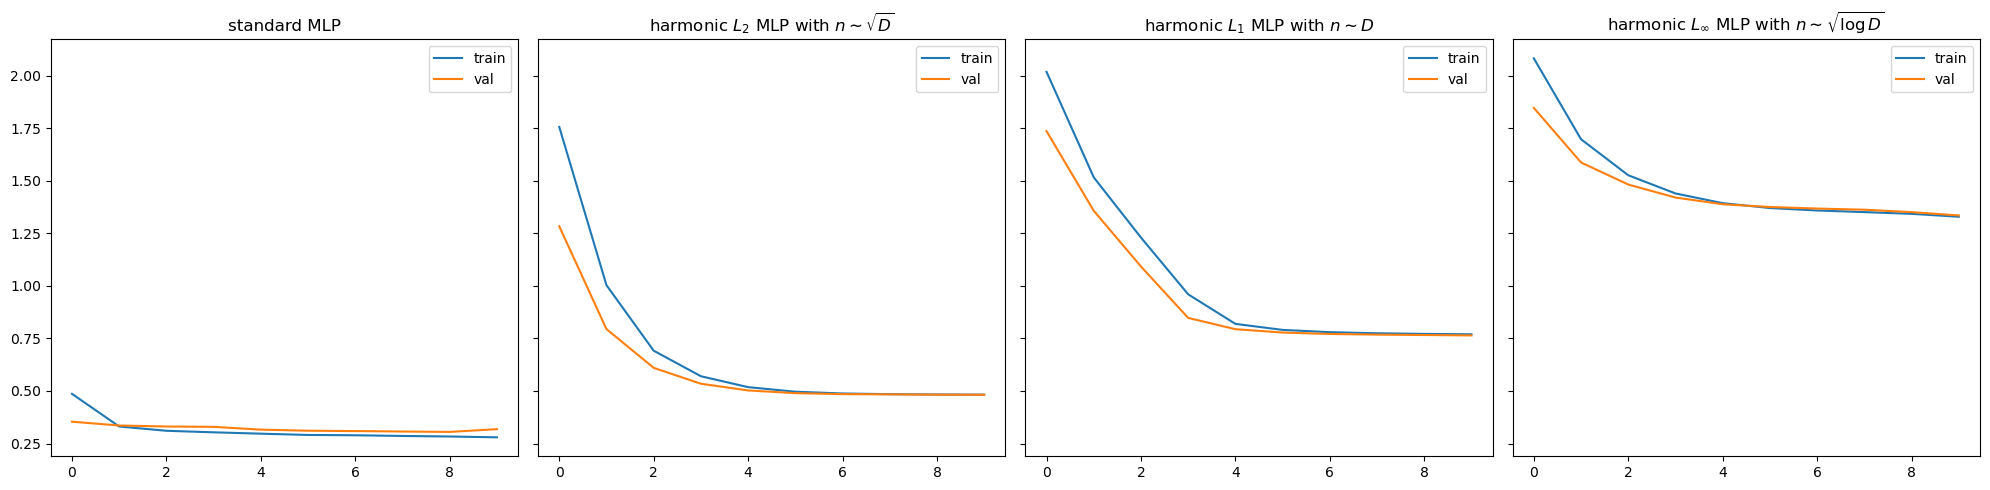

In [184]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5), sharex=True, sharey=True)

for train_history, val_history, name, ax in zip(train_histories, val_histories, models.keys(), axes):

    ax.set_title(name)
    ax.plot(train_history, label='train')
    ax.plot(val_history, label='val')
    ax.legend()

plt.tight_layout()

In [185]:
test_accs, test_losses = [], []

for name, model in models.items():

    test_acc, test_loss = 0, 0
    # VALIDATION STEP
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
            preds = model(images)
            loss = F.nll_loss(torch.log(preds), labels)
            test_loss += loss.item()
            test_acc += sum(preds.argmax(dim=-1) == labels).item()

    test_losses.append(test_loss)
    test_accs.append(test_acc / len(test))

In [186]:
test_losses, test_accs

([0.29475274682044983,
  0.4586275815963745,
  0.7398678660392761,
  1.3152670860290527],
 [0.9132, 0.8937, 0.8448, 0.5251])

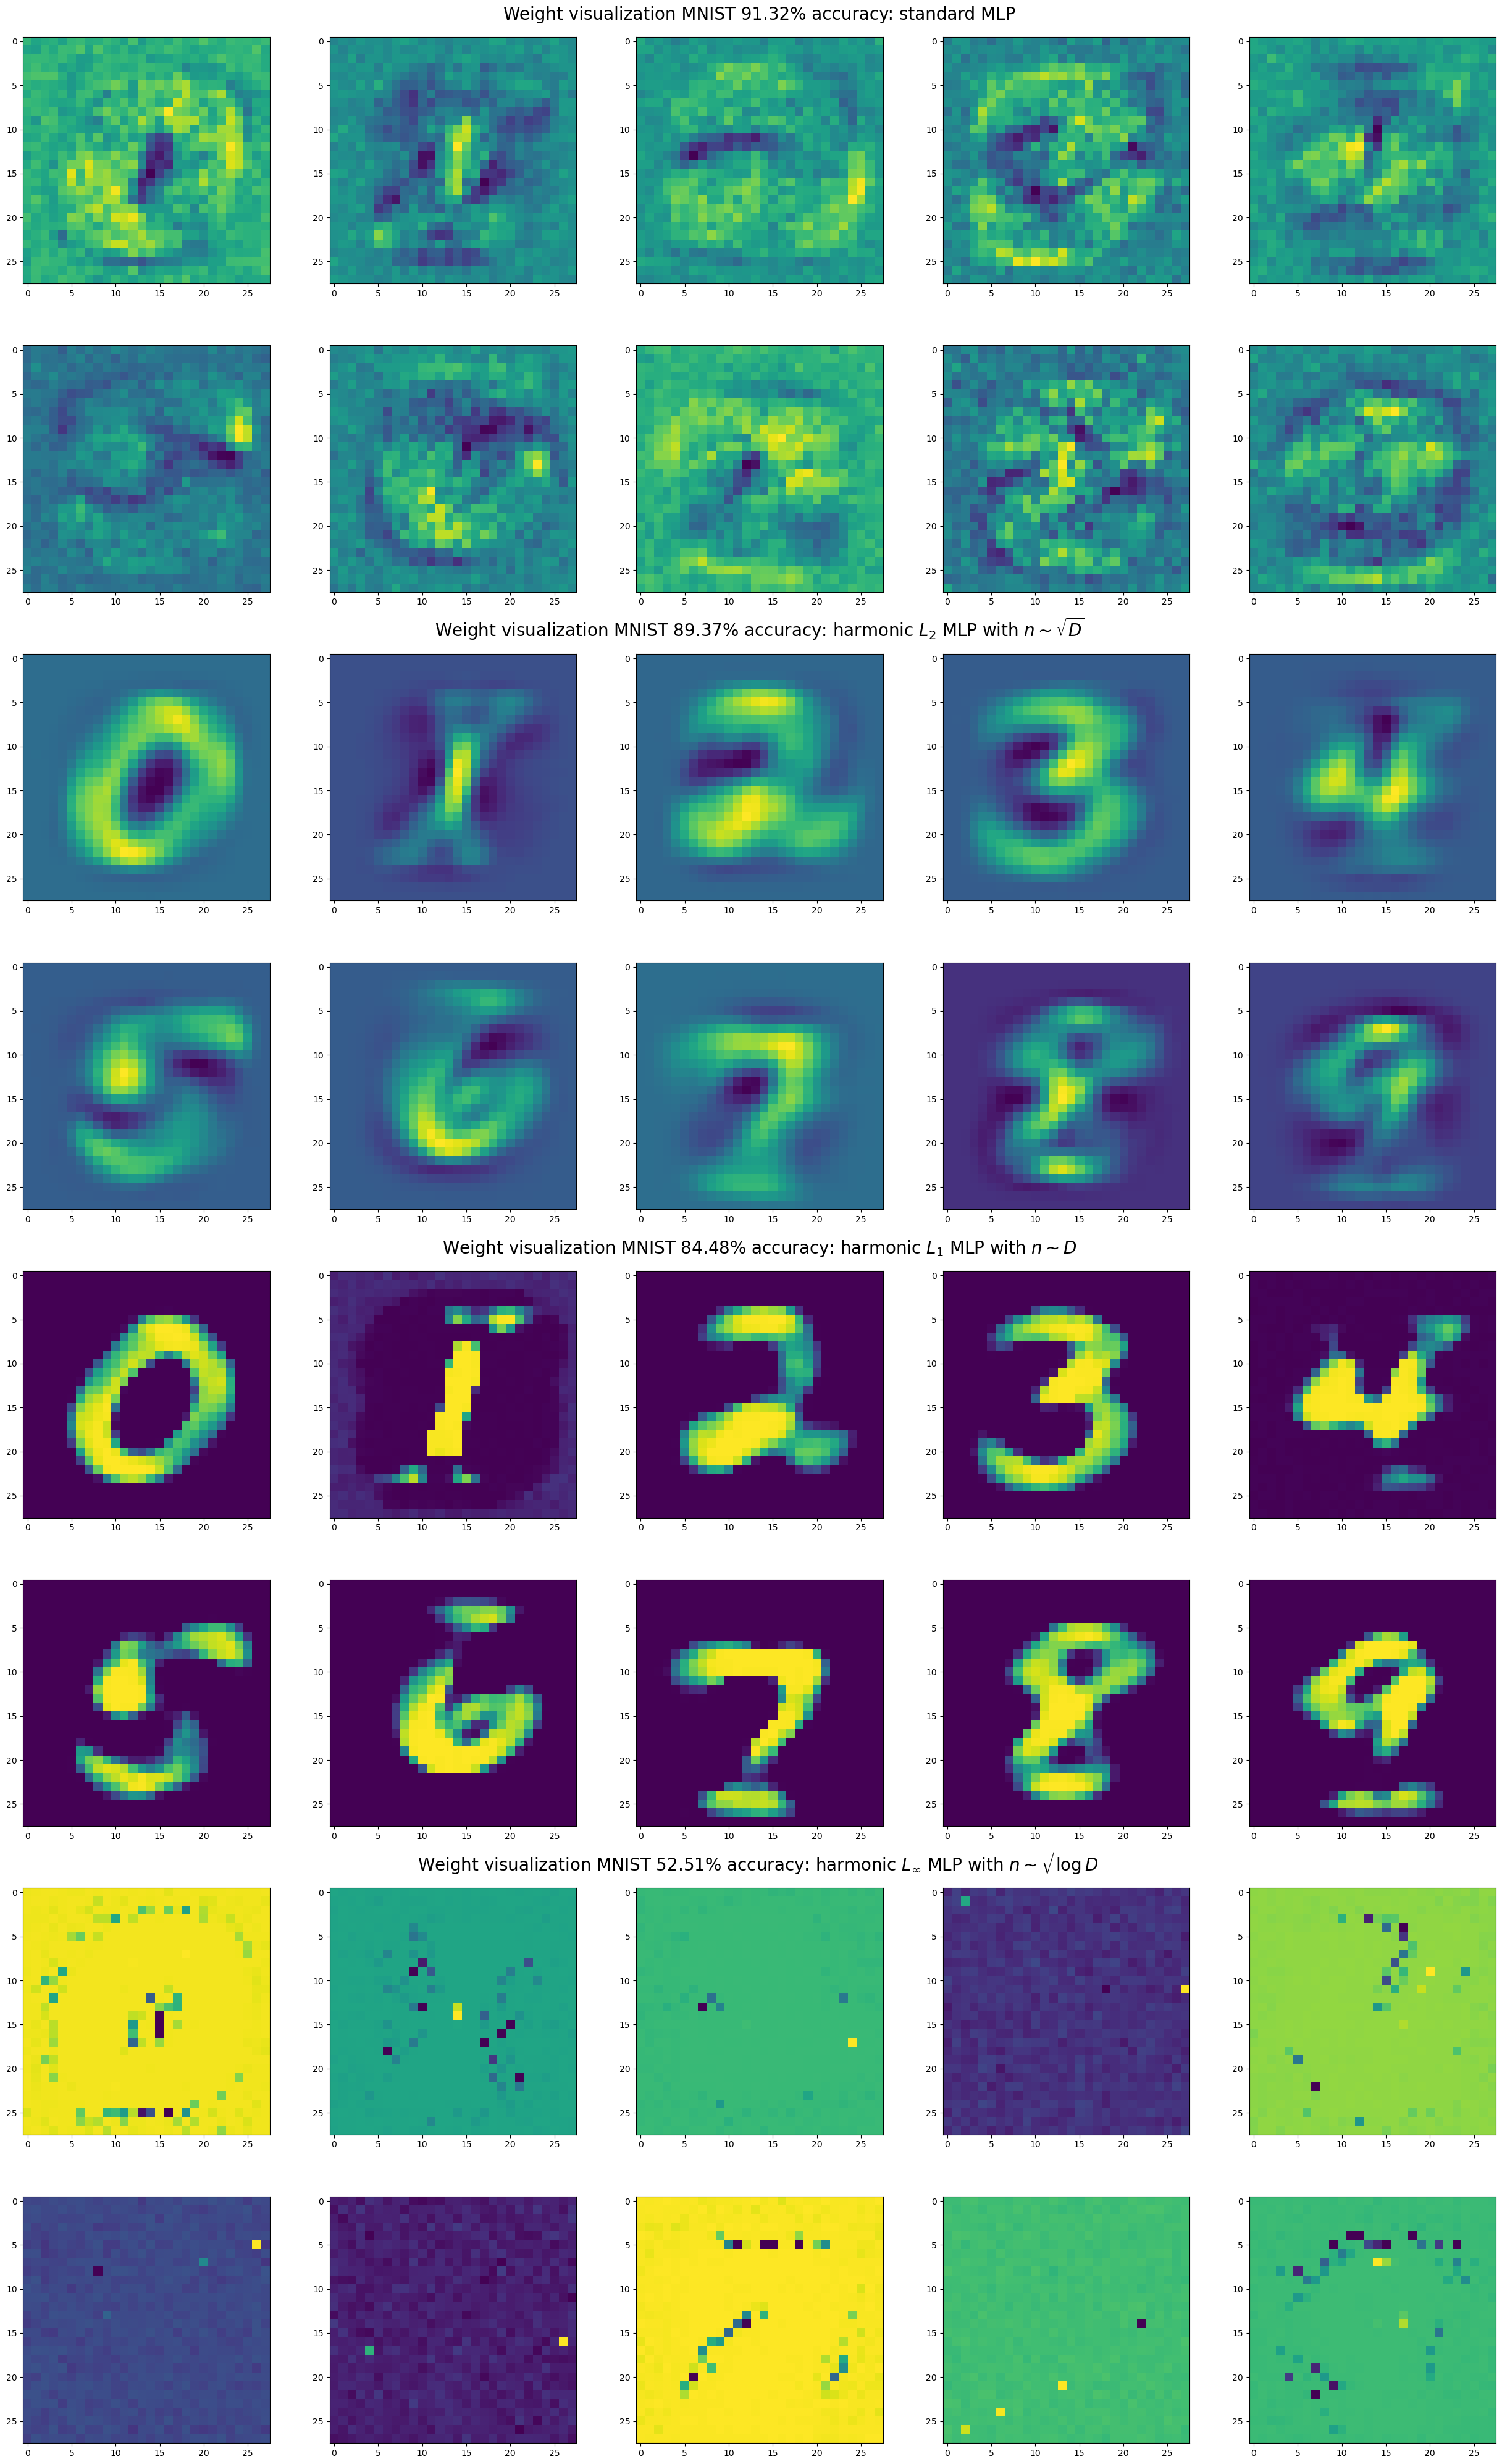

In [187]:
fig, axes = plt.subplots(2*len(models), 5, figsize=(25, 5*2*len(models)))

axes = axes.reshape(len(models), -1)

weights = [model.w.detach().cpu().numpy().reshape(28, 28, -1) for _, model in models.items()]

for j, (w, acc) in enumerate(zip(weights, test_accs)):

    axes[j, 2].set_title(f"Weight visualization MNIST {acc*100:.2f}% accuracy: " + list(models.keys())[j], fontsize=20, pad=20)
    for i, ax in enumerate(axes[j]):
        ax.imshow(w[:, :, i])

plt.tight_layout()